**PRÁCTICA 3**

-Camila Montiel Zapata
-Luisa Fernanda Llamas

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

In [123]:
def RMS_FUNC():
    RMS_V = np.sqrt((1/N)*np.mean(x_i**2))
    return RMS_V


In [124]:
signal = sio.loadmat('signals (1).mat')
senales = signal['Fs']
print(f'Frecuencia de muestreo: {senales}')
senal_ = senales.flatten()
NC = len(senal_)
print(signal.keys())
print('el tamaño de la señal es:',senales.shape)

Frecuencia de muestreo: [[1024]]
dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])
el tamaño de la señal es: (1, 1)


In [125]:
#Señales ECG Y EMG CRUDAS
senalECG = signal['ECG_asRecording']
senal_fR = senalECG.flatten()
NC = len(senal_fR)

senalEMG1R = signal['EMG_asRecording1']
senal_fEMG = senalEMG1R.flatten()
NEMG = len(senal_fEMG)  

senalEMG2R = signal['EMG_asRecording2']
senal_EMG2 = senalEMG2R.flatten()  
NEMG2 = len(senal_EMG2)

#Señales ECG Y EMG FILTRADAS
senalECG_f = np.array(signal['ECG_filtered'])
senal_fECG = senalECG_f.flatten()


senalEMG1_f = signal['EMG_filtered1']
senal_fEMG1 = senalEMG1_f.flatten()
NEMG1 = len(senal_fEMG1)    

senal_fEMG2_f = signal['EMG_filtered2']
senal_fEMG2 = senal_fEMG2_f.flatten()       
NEMG2_f = len(senal_fEMG2)
print('la longitud de la señal es:', NEMG2_f) 

la longitud de la señal es: 30721


In [126]:
fs = 1024  # Frecuencia de muestreo (Hz)
t_f1 = np.arange(NC)/fs
t_f2 = np.arange(NEMG1)/fs
tiempo_1 = (0,t_f1+fs, fs)
tiempo_2 = (0,t_f2+fs, fs)

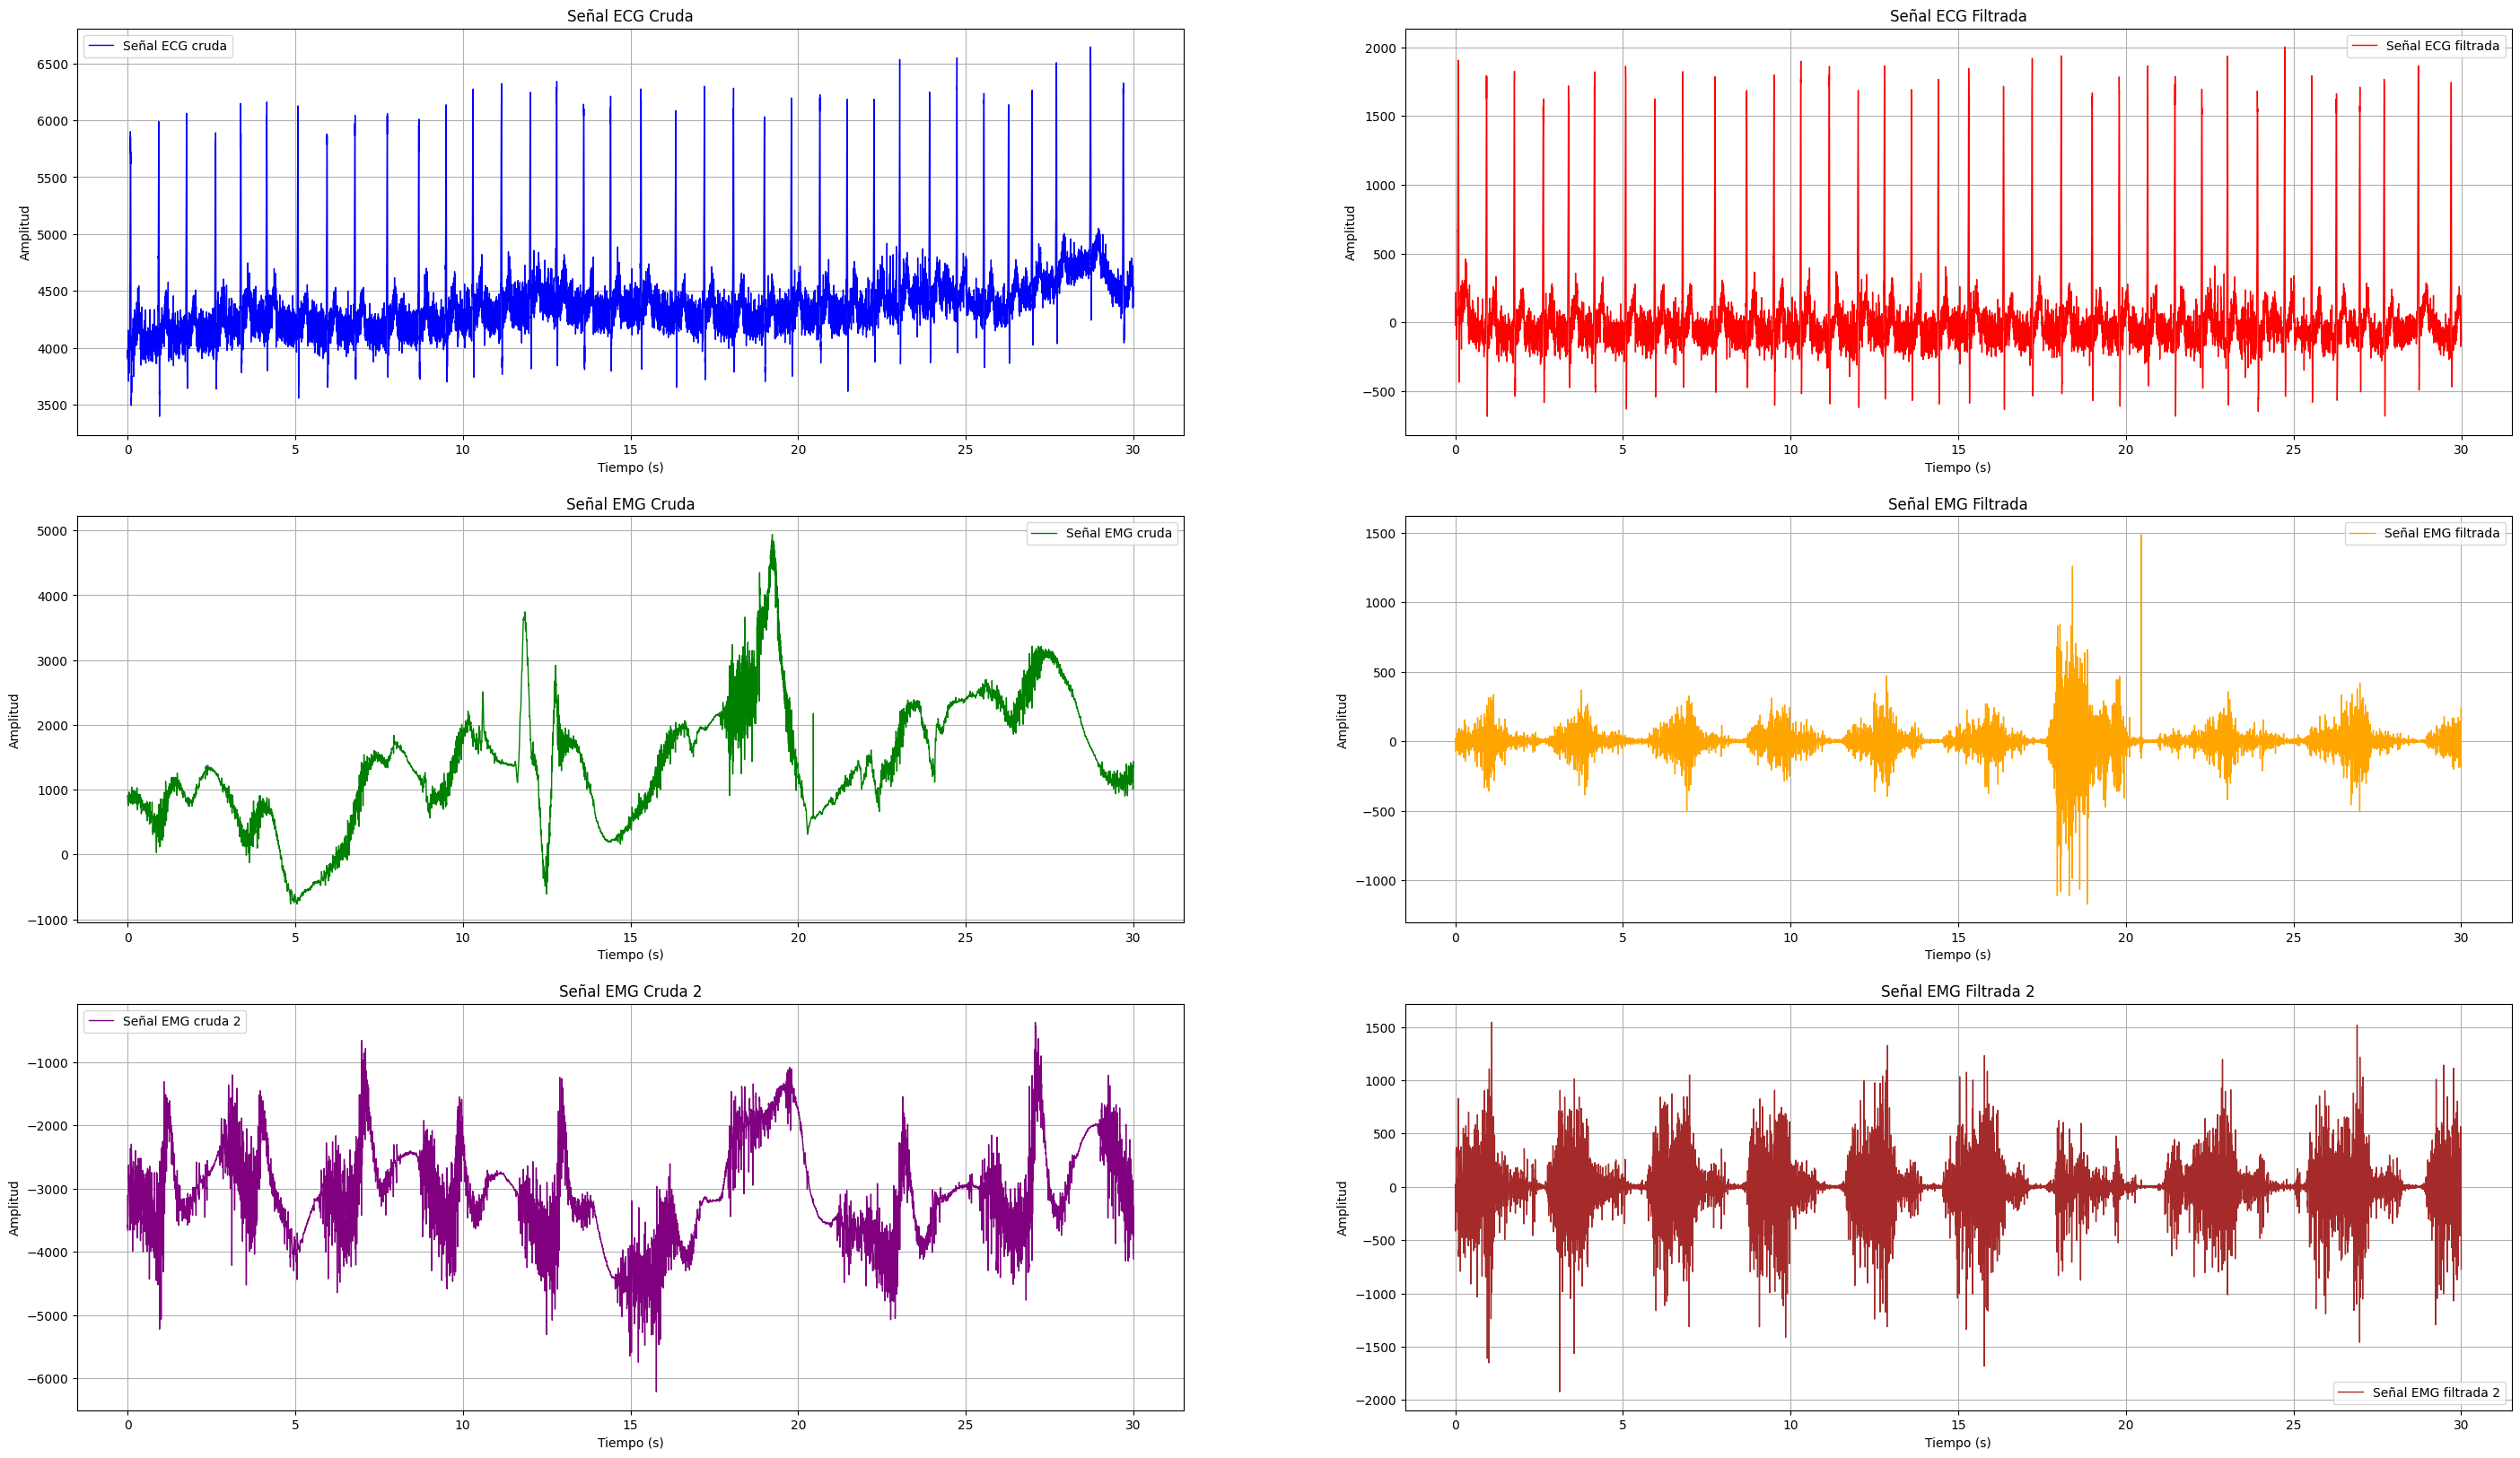

In [179]:
plt.figure(figsize=(35, 20))
plt.subplot(3, 2, 1)
plt.plot(t_f1, senal_fR, label='Señal ECG cruda', color='blue' , linewidth=1)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG Cruda')
plt.legend()
plt.grid(True)
plt.subplot(3, 2, 2)
plt.plot(t_f1, senal_fECG, label='Señal ECG filtrada', color='red' , linewidth=1)   
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG Filtrada')
plt.legend()
plt.grid(True)
plt.subplot(3, 2, 3)
plt.plot(t_f2, senal_fEMG, label='Señal EMG cruda', color='green' , linewidth=1)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal EMG Cruda')
plt.legend()
plt.grid(True)                  
plt.subplot(3, 2, 4)
plt.plot(t_f2, senal_fEMG1, label='Señal EMG filtrada', color='orange' , linewidth=1)   
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal EMG Filtrada')
plt.legend()
plt.grid(True)
plt.subplot(3, 2, 5)
plt.plot(t_f2, senal_EMG2, label='Señal EMG cruda 2', color='purple' , linewidth=1)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal EMG Cruda 2')
plt.legend()
plt.grid(True)
plt.subplot(3, 2, 6)
plt.plot(t_f2, senal_fEMG2, label='Señal EMG filtrada 2', color='brown' , linewidth=1)   
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal EMG Filtrada 2')
plt.legend()
plt.grid(True)

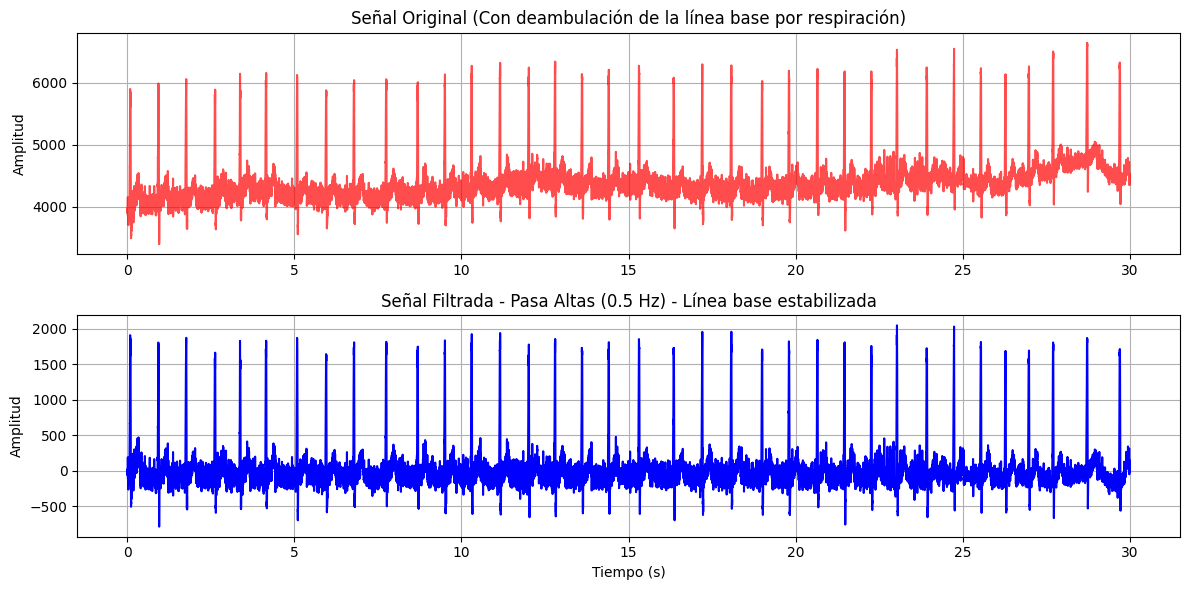

In [160]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# === 1. DEFINIR LA FUNCIÓN DEL FILTRO PASA ALTAS ===
def aplicar_pasa_altas(senal, fs, f_corte, orden=4):
    """
    Aplica un filtro pasa altas Butterworth a una señal.
    f_corte: Frecuencia por debajo de la cual se bloquea el ruido (ej. 0.5 Hz).
    """
    # 1. Diseñar el filtro pasa altas ('highpass')
    b, a = signal.butter(orden, f_corte, btype='highpass', fs=fs)
    
    # 2. Aplicar el filtro sin desfase temporal
    senal_limpia = signal.filtfilt(b, a, senal)
    
    return senal_limpia

# === 2. SIMULACIÓN DE DATOS (O usa los tuyos de signals.mat) ===
fs = 1024  # Frecuencia de muestreo

senal_filtrada_pa = aplicar_pasa_altas(senal_fR, fs=fs, f_corte=0.5)

senal_detrend = signal.detrend(senal_filtrada_pa)
# === 4. GRAFICAR ===
plt.figure(figsize=(12, 6))

# Gráfica Arriba: Original con oscilación lenta
plt.subplot(2, 1, 1)
plt.plot(t_f1, senal_fR, color='red', alpha=0.7)
plt.title('Señal Original (Con deambulación de la línea base por respiración)')
plt.ylabel('Amplitud')
plt.grid(True)

# Gráfica Abajo: Filtrada
plt.subplot(2, 1, 2)
plt.plot(t_f1, senal_detrend, color='blue')
plt.title('Señal Filtrada - Pasa Altas (0.5 Hz) - Línea base estabilizada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()


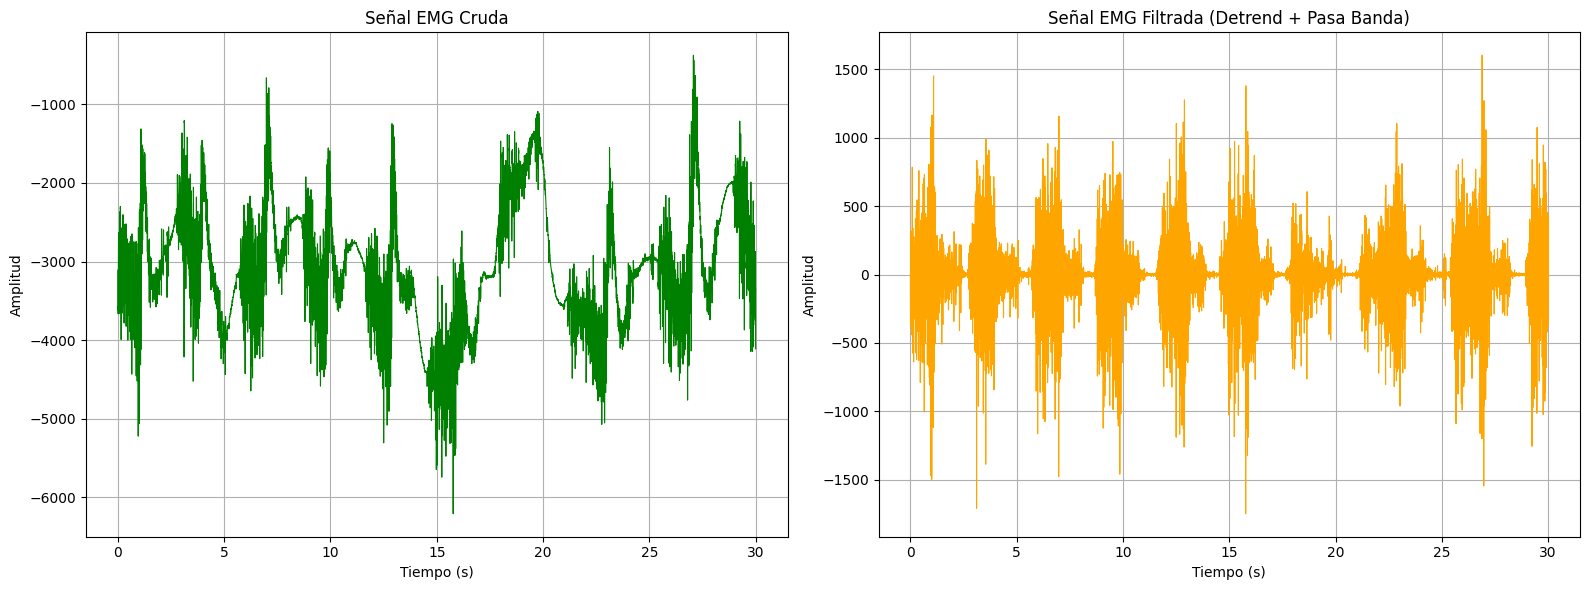

In [182]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# === 1. DEFINIR EL FILTRO PASA BANDA PARA EMG ===
def limpiar_emg_crudo(senal, fs, f_baja=20.0, f_alta=450.0, orden=4):
    """
    Aplica un filtro pasa banda (ej. 20 Hz - 450 Hz) típico para EMG.
    Elimina la deambulación de la línea base (olas lentas) conservando los datos negativos.
    """
    # Se diseña el filtro pasa banda
    b, a = signal.butter(orden, [f_baja, f_alta], btype='bandpass', fs=fs)
    
    # Se aplica el filtro
    senal_limpia = signal.filtfilt(b, a, senal)
    return senal_limpia

# === SIMULACIÓN DE TUS DATOS (Reemplaza con tus variables) ===
fs = 1024  # Asegúrate de usar la frecuencia de muestreo de tu archivo


# === 2. APLICAR EL PROCESAMIENTO ===

# Paso A: Aplicar detrend para centrar la señal en cero matemáticamente
#senal_centrada = signal.detrend(senal_EMG2)

# Paso B: Aplicar el filtro pasa banda para eliminar las oscilaciones lentas
senal_filtrada = limpiar_emg_crudo(senal_centrada, fs=fs, f_baja=20.0, f_alta=450.0)

# === 3. GRAFICAR (Idéntico a tus imágenes) ===
plt.figure(figsize=(16, 6))

# Gráfica Izquierda: EMG Crudo
plt.subplot(1, 2, 1)
plt.plot(t_f2, senal_EMG2, color='green', linewidth=0.8)
plt.title('Señal EMG Cruda')
plt.ylabel('Amplitud')
plt.xlabel('Tiempo (s)')
plt.grid(True)

# Gráfica Derecha: EMG Filtrado (Centrado y conservando negativos)
plt.subplot(1, 2, 2)
plt.plot(t_f2, senal_filtrada, color='orange', linewidth=0.8)
plt.title('Señal EMG Filtrada (Detrend + Pasa Banda)')
plt.ylabel('Amplitud')
plt.xlabel('Tiempo (s)')
plt.grid(True)

plt.tight_layout()
plt.show()

En los graficos anteriores se aprecia lo siguiente: 
** a) ** Al analizar las gráficas del ECG, se observa que la señal original (azul) presenta una ligera inclinación hacia el final del registro y resulta poco legible. Estas alteraciones suelen deberse a factores físicos, como el movimiento del tórax durante la respiración del paciente, lo que genera oscilaciones lentas que distorsionan el trazo. Como se evidencia en la señal resultante (roja), estos problemas se corrigen aplicando un proceso en dos partes. Primero, es necesario enderezar matemáticamente la gráfica para eliminar cualquier pendiente o desnivel, esta acción la cumple la función detrend. Posteriormente, se requiere implementar una barrera que bloquee esas ondas lentas causadas por la respiración, permitiendo que crucen únicamente las frecuencias rápidas de los latidos eléctricos cardíacos; este comportamiento es exactamente el que realiza un filtro pasa altas.
** b) **

**Referencias**


1. Fig. 3 Different techniques for EMG signal processing. (n.d.). ResearchGate. https://www.researchgate.net/figure/Different-techniques-for-EMG-signal-processing_fig3_339515985

2. Kligfield, P., Gettes, L. S., Bailey, J. J., Childers, R., Deal, B. J., Hancock, E. W., Van Herpen, G., Kors, J. A., Macfarlane, P., Mirvis, D. M., Pahlm, O., Rautaharju, P., & Wagner, G. S. (2007). Recommendations for the standardization and interpretation of the electrocardiogram. Circulation, 115(10), 1306–1324. https://doi.org/10.1161/circulationaha.106.180200

3. Yousif, H. A., Norasmadi, A. R., Salleh, A. F. B., Ammar, Z., & Alfarhan, K. A. (2019). Assessment of Muscles Fatigue during 400-Meters Running Strategies Based on the Surface EMG Signals. Journal of Biomimetics, Biomaterials and Biomedical Engineering, 42, 1–13. https://doi.org/10.4028/www.scientific.net/jbbbe.42.1